# Inteligencia Artificial
### Grado Ingeniería Informática Tecnologías Informáticas 

### Práctica redes neuronales

In [1]:
import random, math

En esta práctica vamos a implementar algunas ideas básicas del tema 7 (Introducción a las Redes Neuronales). En concreto:

- Cómo calcular la salida de una red neuronal a a partir de una entrada dada.
- Cómo usar redes neuronales como clasificadores.
- Medir el rendimiento de una red sobre un conjutnto de ejemplos.
- Medir el error cuadrático que comete una red sobre un conjunto de ejemplos. 
- Aprendizaje en redes neuronales (sólo en el caso particular de perceptrones)

### Parte 1: cálculo de la salida de una red

#### Ejercicio 1

Definir en python las funciones de activación `relu` y `sigmoide`

In [2]:
##### Solución: 
def relu(x):
    return max(0,x)

def sigmoide(x):
    return 1/(1+math.exp(-x)) #exp es e^x

#### Ejercicio 2

Vamos a implementar en este ejercicio el cálculo que realiza una red neuronal multicapa hacia adelante, con la siguiente estructura:

- Una capa de entrada de 16 unidades (numeradas de la 1 a la 16)
- Una capa oculta intermedia de 3 unidades (numeradas 17, 18 y 19), con función de activación ReLU. 
- Una capa de salida con una única unidad (la número 20), con el sigmoide como función de activación. 

<div>
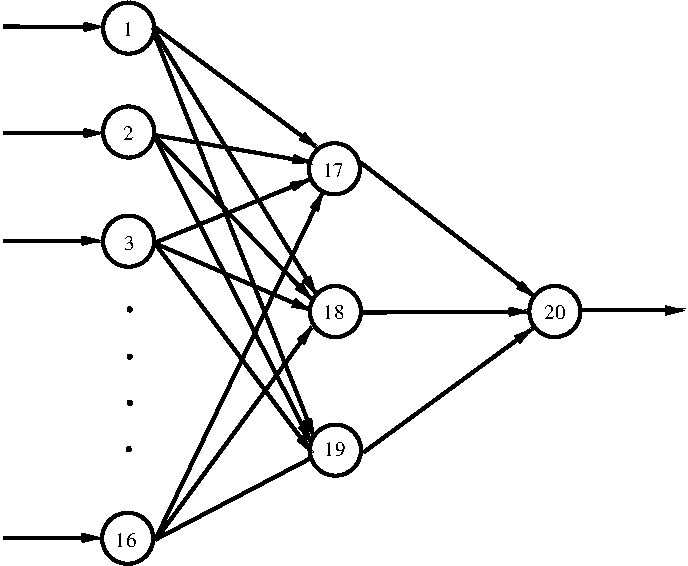
</div>

Lo que siguen son los pesos (y umbrales) de esta red, que llamaremos `rv1`. Usaremos el convenio según el cual la variable `rv1_pesos<i>` tiene asignados la lista de los pesos de las conexiones que llegan a la unidad $i$. Igualmente la variable `rv1_umbral<i>` referencia al peso umbral de la unidad $i$. 

In [3]:
# Capa oculta 1
rv1_pesos17=[0.57,1.39,0.4,2.1,1.71,0.30,1.55,0.73,1.49,3.07,1.69,1.2,1.82,0.2,0.13,0.38]
rv1_umbral17=-0.6
rv1_pesos18=[0.57,1.39,0.41,2.1,1.71,0.31,1.55,0.74,1.49,3.07,1.69,1.2,1.82,0.21,0.13,0.38]
rv1_umbral18=-0.22
rv1_pesos19=[0.71,1.80,-5.67,5.77,1.52,2.04,0.45,0.67,-2.22,2.27,-2.41,-1.44,1.92,-2.95,2.01,2.62]
rv1_umbral19=-2.03
# Capa de salida
rv1_pesos20=[-3.14,3.97,-2.81]
rv1_umbral20=1.8

Se pide implementar una función `f_rv1(l)` que lleva a cabo el cálculo que realiza la red `rv1`, recibiendo como entrada una lista `l` con 16 números.

In [7]:
# Solución:

def f_rv1(l):
    in17= rv1_umbral17
    in18= rv1_umbral18
    in19= rv1_umbral19
    for i in range(len(l)):
        in17+= l[i]*rv1_pesos17[i]
        in18+= l[i]*rv1_pesos18[i]
        in19+= l[i]*rv1_pesos19[i]
    a17=relu(in17)
    a18=relu(in18)
    a19=relu(in19)
    in20= rv1_umbral20 + sum(peso*act for peso,act in zip(rv1_pesos20,[a17,a18,a19]))

    return sigmoide(in20)






Ejemplos:

In [10]:
f_rv1([-1,  1, -1, -1,  1,  1, -1, -1,  0, -1, -1,  1,  1,  1, -1,  1])
# Resultado: 0.8581489350995123

0.8581489350995123

In [ ]:

f_rv1([-2.12, 3.2, -1.5, 2.3,  8.4, -3.1, -1.21, 0.34,  0.21, -2.65, -4.1,  2.1,  6.7,  5.2, -8.345,  11.41])
# Resultado: 3.1810610757510064e-41

3.181061075750961e-41

#### Ejercicio 3

Implementar ahora la función `f_rv2` que calcula la salida de una red que llamaremos `rv2`, que tiene la misma estructura que la red `rv1`del ejercicio anterior, pero con los siguientes pesos:

In [12]:
# Capa oculta 1
rv2_pesos17=[2.19,-0.42,-0.13,2.67,-1.35,2.2,-1.55,2.06,-1.94,0.38,-0.69,-0.91,-0.85,-1.94,0.12,-0.15]
rv2_umbral17=1.81
rv2_pesos18=[-2.07,-2.59,-2.59,-2.69,1.77,-2.59,-2.87,2.72,1.0,-2.53,-2.5,-1.17,-1.24,1.03,-0.95,2.62]
rv2_umbral18=2.08
rv2_pesos19=[-0.87,-2.58,2.62,2.84,-1.15,0.4,-0.57,2.73,-1.0,0.81,-1.31,2.0,1.46,-2.15,-0.66,-2.34]
rv2_umbral19=-0.07
# Capa de salida
rv2_pesos20=[2.02, -1.04, 0.02]
rv2_umbral20=3.11

In [18]:
# Solución:

def f_rv2(l):
    in17= rv2_umbral17
    in18= rv2_umbral18
    in19= rv2_umbral19
    for i in range(len(l)):
        in17+= l[i]*rv2_pesos17[i]
        in18+= l[i]*rv2_pesos18[i]
        in19+= l[i]*rv2_pesos19[i]
    a17=relu(in17)
    a18=relu(in18)
    a19=relu(in19)
    in20= rv2_umbral20 + sum(peso*act for peso,act in zip(rv2_pesos20,[a17,a18,a19]))

    return sigmoide(in20)





Ejemplos:

In [19]:
f_rv2([-1,  1, -1, -1,  1,  1, -1, -1,  0, -1, -1,  1,  1,  1, -1,  1])
# Resultado: 2.0083337163682923e-05

2.008333716368296e-05

In [21]:

f_rv2([-2.12, 3.2, -1.5, 2.3,  8.4, -3.1, -1.21, 0.34,  0.21, -2.65, -4.1,  2.1,  6.7,  5.2, -8.345,  11.41])
# Resultado: 3.1810610757510064e-41

3.1029676990030793e-32

***

Vamos ahora a considerar una estructura de red que tiene más de una unidad en la capa de salida y que usa _softmax_ para transformar la salida de la última capa a una distribución de probabilidad. 

#### Ejercicio 4

Definir en python la función `softmax(l)`, donde `l` es la lista de sus argumentos.

In [22]:
# Solución:

def softmax(l):
    suma_exp = sum(math.exp(x) for x in l)
    return [math.exp(x)/suma_exp for x in l]







Ejemplos:

In [23]:
softmax([9,3,6,-2,1])
# Resultado: 
# [0.9500122688103602,
#  0.002354844979173426,
#  0.04729832577757093,
#  1.5866820660733065e-05,
#  0.0003186936122347509]

[0.9500122688103602,
 0.002354844979173426,
 0.04729832577757093,
 1.5866820660733065e-05,
 0.0003186936122347509]

In [24]:
softmax([2.8,-0.25,3.25,4.145,3.12,-5.21,0.1])
# Resultado:
#[0.12660594814771753,
# 0.005995921525796463,
# 0.1985576512356019,
# 0.4859372461404638,
# 0.17435256632430038,
# 4.204896495025608e-05,
# 0.00850861766116953]


[0.12660594814771756,
 0.005995921525796464,
 0.19855765123560193,
 0.4859372461404639,
 0.1743525663243004,
 4.2048964950256094e-05,
 0.008508617661169532]

#### Ejercicio 5

Consideremos una red neuronal multicapa hacia adelante, `ri1` con la siguiente estructura:

- Una capa de entrada de 4 unidades (numeradas de la 1 a la 4)
- Una capas oculta de 2 unidades (unidades 5 y 6), con función de activación ReLU.
- Otra capa oculta igual a la anterior (unidades 6 y 7)
- Una capa de salida con tres unidades(unidades 8, 9 y 10), que usa softmax. 

<div>
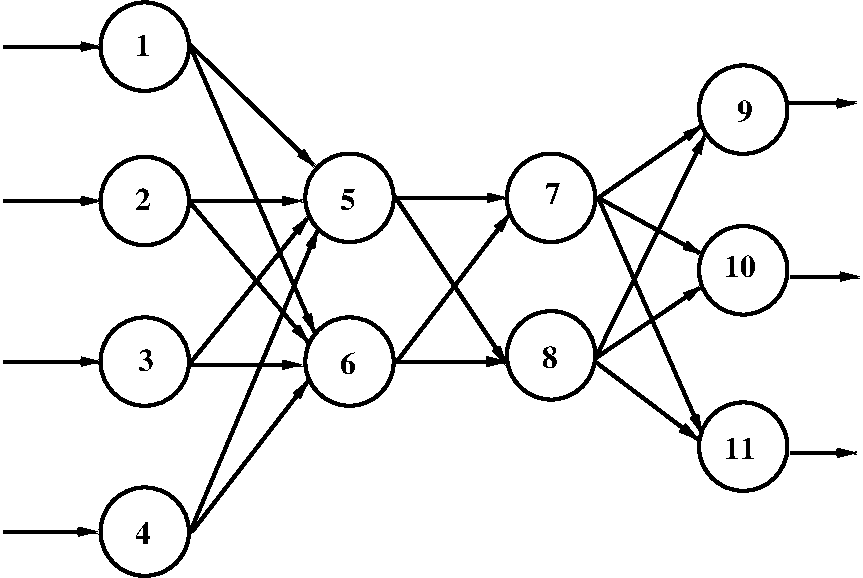
</div>

Los pesos de la red `ri1` son los siguientes:

In [25]:
# Capa oculta 1
ri1_pesos5=[1.55, 0.76, 1.91, 0.18]
ri1_umbral5=-0.47
ri1_pesos6=[-0.31, -0.94, 1.47, -1.53]
ri1_umbral6=2.21

# Capa oculta 2
ri1_pesos7=[-2.93, 1.23]
ri1_umbral7=1.12
ri1_pesos8=[2.21, 0.93]
ri1_umbral8=-2.03

# Capa de salida
ri1_pesos9=[0.69, -2.64]
ri1_umbral9=0.35
ri1_pesos10=[-1.16, 2.94]
ri1_umbral10=-1.47
ri1_pesos11=[0.33, -1.69]
ri1_umbral11=-0.2

Se pide implementar una función `f_ri1(l)` que lleva a cabo el cálculo que realiza la red ri1, recibiendo como entrada una lista l con 4 números.

In [26]:
# Solución:
def f_ri1(l):

    in5=ri1_umbral5 + sum(w*i for w,i in zip(ri1_pesos5,l))
    in6=ri1_umbral6 + sum(w*i for w,i in zip(ri1_pesos6,l))
    a5=relu(in5)
    a6=relu(in6)

    in7= ri1_umbral7 + sum (w*i for w,i in zip(ri1_pesos7,[a5,a6]))
    in8= ri1_umbral8 + sum (w*i for w,i in zip(ri1_pesos8,[a5,a6]))
    a7=relu(in7)
    a8=relu(in8)

    in9= ri1_umbral9 +sum(w*i for w,i in zip(ri1_pesos9,[a7,a8]))
    in10= ri1_umbral10 +sum(w*i for w,i in zip(ri1_pesos10,[a7,a8]))
    in11= ri1_umbral11 +sum(w*i for w,i in zip(ri1_pesos11,[a7,a8]))

    return softmax([in9,in10,in11])






Ejemplos:

In [27]:
f_ri1([0.34,-0.25,1.45,6.89])
# Resultado: [8.864658601047536e-16, 0.9999999999997443, 2.547083041003686e-13]

[8.864658601047536e-16, 0.9999999999997443, 2.547083041003686e-13]

In [28]:
f_ri1([-3.21,-0.89,-5.21,3.51])
# Resultado: [0.7112831207942694, 0.014513373741990734, 0.27420350546373984]

[0.7112831207942694, 0.014513373741990734, 0.27420350546373984]

In [29]:
f_ri1([6.0,2.2,4.0,1.0])
# Resultado: [4.488792822216351e-99, 1.0, 1.9572652640765038e-82]

[4.488792822216351e-99, 1.0, 1.9572652640765038e-82]

#### Ejercicio 6

Definir ahora la correspondiente función `f_ri2(l)` para otra red `ri2` con la misma estructura que la anterior, pero con un conjunto de pesos diferente:

In [30]:
# Capa oculta 1
ri2_pesos5=[-0.93,-0.48,-0.47,-0.18]
ri2_umbral5=0.72
ri2_pesos6=[-1.18, -0.66, 2.40, 2.65]
ri2_umbral6=-0.83

# Capa oculta 2
ri2_pesos7=[0.2,-0.62]
ri2_umbral7=-1.33
ri2_pesos8=[-0.05,1.22]
ri2_umbral8=-1.52

# Capa de salida
ri2_pesos9=[-0.94,-10.15]
ri2_umbral9=4.92
ri2_pesos10=[0.51,6.02]
ri2_umbral10=-1.38
ri2_pesos11=[0.71,6.64]
ri2_umbral11=-3.84

In [ ]:
# Solución:

def f_ri2(l):

    in5=ri2_umbral5 + sum(w*i for w,i in zip(ri2_pesos5,l))
    in6=ri2_umbral6 + sum(w*i for w,i in zip(ri2_pesos6,l))
    a5=relu(in5)
    a6=relu(in6)

    in7= ri2_umbral7 + sum (w*i for w,i in zip(ri2_pesos7,[a5,a6]))
    in8= ri2_umbral8 + sum (w*i for w,i in zip(ri2_pesos8,[a5,a6]))
    a7=relu(in7)
    a8=relu(in8)

    in9= ri2_umbral9 +sum(w*i for w,i in zip(ri2_pesos9,[a7,a8]))
    in10= ri2_umbral10 +sum(w*i for w,i in zip(ri2_pesos10,[a7,a8]))
    in11= ri2_umbral11 +sum(w*i for w,i in zip(ri2_pesos11,[a7,a8]))

    return softmax([in9,in10,in11])


Ejemplos:

In [32]:
f_ri2([0.34,-0.25,1.45,6.89])
# Resultado: [9.70850404721349e-170, 4.861650436751122e-06, 0.9999951383495632]

[9.70850404721349e-170, 4.861650436751122e-06, 0.9999951383495632]

In [33]:
f_ri2([-3.21,-0.89,-5.21,3.51])
# Resultado: [0.9980107755155126, 0.00183265195460546, 0.00015657252988188292]

[0.9980107755155126, 0.00183265195460546, 0.00015657252988188292]

In [36]:
f_ri2([6.0,2.2,4.0,1.0])
# Resultado: [3.5877536494889878e-12, 0.7716967371564146, 0.2283032628399975]

[3.5877536494890023e-12, 0.7716967371564151, 0.2283032628399972]

***

### Parte 2: redes neuronales como clasificadores

En esta segunda parte veremos cómo usar las redes anteriores como clasificadores en problemas de clasificación dados por conjuntos de datos. En esta práctica concretamente usaremos dos conjuntos de datos muy conocidos: el conjunto de datos de los votos y el del iris. El primero de ellos es un problema de clasificación binaria y el segundo es multiclase (tres clases).   

### El conjunto de datos _Votos_ 

Datos sobre votos de cada uno de los 435 congresitas de Estados Unidos en 16 votaciones realizadas durante 1984, clasificados según su partido (republicano o demócrata) (Más información en  http://archive.ics.uci.edu/ml/datasets/Congressional+Voting+Records)

El valor de cada votación lo codificamos numéricamente de la siguiente manera: 

 - 1: voto sí
 - -1: voto no
 - 0: "Present" (similar a la abstención)

El partido lo codificamos de la siguiente manera:

- 0: republicano
- 1: demócrata

Lo que sigue es un subconjunto de 109 ejemplos del _dataset_ original. Los ejemplos y la correspondiente clasificación están separados pero en el mismo orden:

In [37]:
ejemplos_votos=[
 [-1, -1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, 1, 1, -1, 1],
 [1, -1, 1, -1, -1, -1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 0],
 [1, 1, 1, -1, -1, 1, 0, 1, -1, -1, 1, 1, -1, 1, -1, 0],
 [1, -1, 1, 1, -1, -1, -1, 1, 1, 1, -1, -1, -1, 1, 1, 1],
 [0, 0, 0, -1, -1, -1, 1, 1, 1, 1, -1, -1, 1, -1, 1, 1],
 [-1, 1, 1, -1, -1, -1, 1, 1, 1, -1, -1, -1, 1, -1, 0, 0],
 [1, -1, 1, -1, -1, 0, 1, 1, 1, -1, 0, 0, -1, 0, 0, 0],
 [-1, -1, -1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, -1, -1],
 [-1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
 [1, -1, -1, 1, 1, 1, -1, -1, -1, -1, 1, 1, 1, 1, -1, -1],
 [-1, 1, -1, 1, 1, -1, -1, -1, -1, -1, 0, 0, 1, 1, -1, -1],
 [-1, -1, 1, -1, -1, -1, 1, 1, 1, -1, -1, -1, -1, 1, 1, 1],
 [-1, 1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1, 1],
 [1, 1, -1, -1, 1, 1, -1, -1, -1, 1, 1, 1, 1, 1, -1, 0],
 [-1, 1, -1, 1, 1, 1, -1, 0, -1, 1, -1, 1, 1, 1, -1, 0],
 [-1, 1, -1, 1, 1, 1, -1, -1, -1, 1, -1, 1, 1, 1, -1, -1],
 [1, 1, 1, 1, 1, 1, 1, 1, -1, 1, -1, -1, 1, 1, -1, 1],
 [-1, -1, 1, -1, -1, -1, 1, 1, 1, -1, -1, 0, -1, -1, 1, 1],
 [1, 1, -1, -1, -1, -1, 1, 1, 0, -1, 1, -1, -1, -1, 1, 0],
 [-1, 1, -1, 1, 1, 1, -1, -1, -1, 1, -1, 0, 1, 1, -1, -1],
 [1, 1, 1, -1, -1, 0, 1, 1, 1, 1, -1, -1, -1, -1, 1, 0],
 [-1, -1, 0, -1, 1, 1, -1, -1, -1, -1, 1, 1, 1, 1, -1, 1],
 [-1, -1, -1, 1, 1, 1, -1, -1, -1, 1, -1, 1, -1, 1, -1, 1],
 [-1, -1, 1, -1, -1, 1, 1, 1, 1, -1, 1, 1, -1, 1, 1, 0],
 [1, 1, 1, -1, -1, -1, 1, 1, 1, -1, -1, -1, 0, 0, 1, 1],
 [-1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, -1, 1, -1, 1, 0],
 [-1, 1, -1, 1, 1, 1, -1, 0, -1, -1, 0, 0, 0, 1, -1, 0],
 [1, 1, 1, -1, 1, 1, -1, -1, -1, 1, 1, -1, 1, 1, -1, 1],
 [-1, -1, -1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, -1],
 [1, 1, -1, -1, -1, -1, -1, 1, 1, -1, 1, -1, -1, -1, 1, -1],
 [-1, 1, -1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, -1, 0],
 [1, -1, 1, -1, -1, -1, 1, 1, 1, 1, -1, 1, -1, -1, 1, 0],
 [1, 1, 1, -1, -1, 1, 0, 1, 1, -1, 1, -1, 1, -1, 1, 1],
 [-1, 1, 1, -1, 1, 1, -1, -1, -1, 1, 1, 1, 1, 1, -1, 0],
 [1, 1, -1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, 1, -1, 1],
 [-1, 1, 1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, 1, 1],
 [-1, -1, -1, 1, 1, 1, -1, -1, -1, 1, -1, 1, 1, 1, -1, 0],
 [-1, 1, -1, -1, 1, 1, -1, -1, 0, -1, -1, 1, 1, 1, -1, 1],
 [1, 1, 1, -1, -1, -1, 1, 1, 1, 1, 1, -1, 1, -1, -1, 1],
 [-1, 1, 1, -1, 0, 1, 1, 1, 1, 1, 1, -1, -1, 0, -1, 0],
 [-1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, 1, 1, -1, 1],
 [1, 1, -1, -1, 1, 0, -1, -1, -1, -1, 1, -1, 1, 1, -1, 1],
 [-1, 1, 1, -1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, 1],
 [1, 1, -1, 1, 1, 1, -1, -1, -1, 1, 1, -1, 1, -1, -1, -1],
 [-1, 1, -1, 1, 1, 1, -1, -1, -1, 1, 1, 1, 1, 1, -1, 1],
 [-1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1],
 [1, -1, 1, -1, 1, 1, 1, -1, 0, -1, 1, -1, 1, 1, 1, 0],
 [-1, 1, 1, -1, -1, 1, -1, 1, 1, -1, 1, -1, 1, -1, 1, 1],
 [-1, 1, -1, 1, 1, 1, -1, -1, -1, 1, -1, 1, 1, 0, -1, 0],
 [-1, 1, 1, -1, -1, 1, -1, 1, 1, -1, 1, -1, 0, 0, 0, 0],
 [-1, -1, -1, 1, 1, 1, -1, -1, -1, 1, -1, 1, 1, 1, -1, -1],
 [1, 1, 1, -1, 0, 1, -1, 0, -1, -1, 1, -1, 1, 1, -1, 0],
 [1, -1, 1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, 1, 1],
 [-1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, -1, -1, -1, -1, 1],
 [-1, -1, -1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, -1, 0],
 [1, 0, 1, -1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, 1, 1],
 [-1, 1, -1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 0, 1, 1, 1],
 [1, 1, 1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, 1, 0],
 [-1, -1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, -1, -1, 0, 1],
 [1, 1, -1, 1, 1, 1, -1, 0, -1, -1, 1, 1, 1, 1, -1, -1],
 [-1, -1, 1, -1, -1, -1, 1, 1, 1, 1, 1, -1, 0, -1, 1, 0],
 [1, 1, 1, -1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1],
 [-1, 1, -1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, -1, -1],
 [1, -1, -1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1],
 [-1, -1, 1, -1, -1, 1, 1, 0, 1, 1, 1, -1, -1, -1, 1, 1],
 [-1, 1, -1, -1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1],
 [-1, 1, -1, 1, 1, 1, -1, -1, -1, 1, -1, 1, 1, 1, -1, 0],
 [-1, 1, 1, -1, 1, 0, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1],
 [-1, 0, -1, 1, 1, 1, -1, -1, -1, 1, -1, 1, 1, 1, -1, -1],
 [1, 1, -1, 1, 1, 1, 1, -1, -1, -1, -1, 1, 1, 1, -1, 1],
 [1, 1, -1, 1, 1, 1, -1, -1, -1, 1, -1, 1, 1, 1, -1, 1],
 [1, -1, 1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, 1, 1],
 [-1, -1, -1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, -1, 1],
 [-1, -1, -1, 1, 1, 1, 1, -1, -1, 1, -1, 1, -1, 1, 1, 1],
 [-1, 1, -1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, -1, -1],
 [-1, -1, -1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 0, 1],
 [1, 1, 1, 0, -1, 1, 1, 1, 1, -1, 1, -1, 1, -1, 0, 1],
 [1, -1, -1, 1, 1, 1, -1, -1, -1, 1, -1, 0, 1, 1, -1, -1],
 [1, -1, -1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, 1, 1],
 [1, 1, 0, 0, 0, 1, -1, -1, -1, -1, 1, -1, 1, -1, -1, 1],
 [-1, -1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, 1, 1, -1, 1],
 [-1, 0, -1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, -1, -1],
 [1, 1, 1, -1, -1, -1, 1, 1, 1, -1, -1, -1, -1, -1, 0, 0],
 [1, -1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1],
 [1, -1, 1, -1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, 1, 1],
 [1, 1, 1, -1, -1, -1, 1, 1, 0, -1, 1, -1, -1, -1, 1, 0],
 [1, -1, 1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, 1, 0],
 [1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1, 0, 1, 1, 1, 1],
 [-1, 1, -1, 1, 1, 1, -1, -1, 1, 1, -1, 1, 1, 1, -1, 1],
 [-1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, -1, 1, 1, 1],
 [1, 1, 1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, 1, -1, 0],
 [1, -1, 1, -1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, 1, 0],
 [-1, 1, -1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, -1, 1],
 [1, 1, -1, 1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, -1, 0],
 [-1, 1, 1, -1, 1, 1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1],
 [1, 1, -1, 1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, -1, 1],
 [-1, -1, -1, 1, 1, 1, -1, -1, -1, 1, -1, 1, 1, 1, 1, -1],
 [-1, -1, -1, 1, 1, 1, -1, -1, -1, 1, -1, 1, -1, 1, -1, 1],
 [-1, 1, -1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, 1, 0, 1],
 [-1, 0, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, 1, -1, 0],
 [1, -1, 1, -1, -1, 1, 1, 1, 1, 1, -1, -1, 1, -1, -1, 1],
 [1, 0, 1, -1, -1, -1, 1, 1, 1, -1, -1, 0, -1, -1, 1, 1],
 [1, 0, 1, -1, -1, -1, 1, 1, 1, -1, -1, -1, 1, -1, 1, 1],
 [-1, -1, 1, -1, -1, -1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 0],
 [1, 1, 1, -1, -1, 0, 1, 1, -1, -1, 1, -1, -1, -1, 1, 1],
 [-1, -1, -1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, -1, 1],
 [-1, 1, 1, -1, -1, 0, 1, 1, 1, 1, 1, -1, 0, 1, 1, 1],
 [-1, 1, -1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 0, 0, -1, 0],
 [-1, -1, 1, 1, 1, 1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1]]   

In [38]:
clases_votos=[1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,
  0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
  0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
  0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
  0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0]

***

### El conjunto de datos _Iris_

Datos sobre la planta de iris y su clasificación entres tipos distintos. Los datos reflejan medidas de la flor de una planta de iris, y su clasificación entre los tipos _Setosa_, _Virgínica_ o _Versicolor_.

Los cuatro atributos son:

- longitud de sépalo
- anchura de sépalo
- longitud de pétalo 
- anchura de pétalo

La clasificación se codifica de la siguiente manera:

- 0: Iris Setosa
- 1: Iris Versicolour
- 2: Iris Virginica

Lo que sigue es un subconjunto de 75 ejemplos del dataset original. Los ejemplos y la correspondiente clasificación están separados pero en el mismo orden:

In [39]:
ejemplos_iris=[
       [5.8, 2.8, 5.1, 2.4],
       [6. , 2.2, 4. , 1. ],
       [5.5, 4.2, 1.4, 0.2],
       [7.3, 2.9, 6.3, 1.8],
       [5. , 3.4, 1.5, 0.2],
       [6.3, 3.3, 6. , 2.5],
       [5. , 3.5, 1.3, 0.3],
       [6.7, 3.1, 4.7, 1.5],
       [6.8, 2.8, 4.8, 1.4],
       [6.1, 2.8, 4. , 1.3],
       [6.1, 2.6, 5.6, 1.4],
       [6.4, 3.2, 4.5, 1.5],
       [6.1, 2.8, 4.7, 1.2],
       [6.5, 2.8, 4.6, 1.5],
       [6.1, 2.9, 4.7, 1.4],
       [4.9, 3.6, 1.4, 0.1],
       [6. , 2.9, 4.5, 1.5],
       [5.5, 2.6, 4.4, 1.2],
       [4.8, 3. , 1.4, 0.3],
       [5.4, 3.9, 1.3, 0.4],
       [5.6, 2.8, 4.9, 2. ],
       [5.6, 3. , 4.5, 1.5],
       [4.8, 3.4, 1.9, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [6.2, 2.8, 4.8, 1.8],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.8, 1.9, 0.4],
       [6.2, 2.9, 4.3, 1.3],
       [5. , 2.3, 3.3, 1. ],
       [5. , 3.4, 1.6, 0.4],
       [6.4, 3.1, 5.5, 1.8],
       [5.4, 3. , 4.5, 1.5],
       [5.2, 3.5, 1.5, 0.2],
       [6.1, 3. , 4.9, 1.8],
       [6.4, 2.8, 5.6, 2.2],
       [5.2, 2.7, 3.9, 1.4],
       [5.7, 3.8, 1.7, 0.3],
       [6. , 2.7, 5.1, 1.6],
       [5.9, 3. , 4.2, 1.5],
       [5.8, 2.6, 4. , 1.2],
       [6.8, 3. , 5.5, 2.1],
       [4.7, 3.2, 1.3, 0.2],
       [6.9, 3.1, 5.1, 2.3],
       [5. , 3.5, 1.6, 0.6],
       [5.4, 3.7, 1.5, 0.2],
       [5. , 2. , 3.5, 1. ],
       [6.5, 3. , 5.5, 1.8],
       [6.7, 3.3, 5.7, 2.5],
       [6. , 2.2, 5. , 1.5],
       [6.7, 2.5, 5.8, 1.8],
       [5.6, 2.5, 3.9, 1.1],
       [7.7, 3. , 6.1, 2.3],
       [6.3, 3.3, 4.7, 1.6],
       [5.5, 2.4, 3.8, 1.1],
       [6.3, 2.7, 4.9, 1.8],
       [6.3, 2.8, 5.1, 1.5],
       [4.9, 2.5, 4.5, 1.7],
       [6.3, 2.5, 5. , 1.9],
       [7. , 3.2, 4.7, 1.4],
       [6.5, 3. , 5.2, 2. ],
       [6. , 3.4, 4.5, 1.6],
       [4.8, 3.1, 1.6, 0.2],
       [5.8, 2.7, 5.1, 1.9],
       [5.6, 2.7, 4.2, 1.3],
       [5.6, 2.9, 3.6, 1.3],
       [5.5, 2.5, 4. , 1.3],
       [6.1, 3. , 4.6, 1.4],
       [7.2, 3.2, 6. , 1.8],
       [5.3, 3.7, 1.5, 0.2],
       [4.3, 3. , 1.1, 0.1],
       [6.4, 2.7, 5.3, 1.9],
       [5.7, 3. , 4.2, 1.2],
       [5.4, 3.4, 1.7, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [6.9, 3.1, 4.9, 1.5]]

In [40]:
clases_iris=[2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0, 2, 1, 0, 2, 2, 1, 0, 1, 1, 1, 2, 0, 2, 0,
       0, 1, 2, 2, 2, 2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 0, 2, 1, 1, 1,
       1, 2, 0, 0, 2, 1, 0, 0, 1]

***

#### Ejercicio 6

- Definir una función `predict_bin(f_red,ejemplo)` que recibe una función `f_red` que implementa una red neuronal con una única unidad de salida con sigmoide (como por ejemplo `f_rv1`o `f_rv2`), y devuelve la clase (0 ó 1) que la red predice para un `ejemplo` de entrada.
- Definir una función `aciertos_bin(f_red,X,y)` que calcula la proporción de aciertos que la red implementada por `f_red` en la clasificación del conjunto de datos dado por `X` (ejemplos) e `y` (clases respectivas). 
- Definir una función `error_cuadrático(f_red,X,y)`, que con los mismos argumentos que la anterior, calcula el error cuadrático que se comete. 

In [47]:
# Solución:

def predict_bin(f_red,ejemplo):
    p=f_red(ejemplo)

    if p>=0.5:
        return 1
    else:
        return 0

def aciertos_bin(f_red,X,y):
    aciertos = 0
    
    for i in range(len(X)):
        # Calculamos la clase asignada a cada dato en X
        c = predict_bin(f_red, X[i])
        
        # Si la clase asignada es la misma que la real: acierto
        if c == y[i]:
            aciertos += 1
    
    return aciertos/len(X)

def error_cuadrático(f_red,X,y):
    return sum((f_red(X[i])-y[i])**2 for i in range(len(X))) / 2


Ejemplos con `predict_bin`:

In [48]:
# Predicción con rv1 para votos, para el ejemplo de índice 12
# -----------------------------------------------------------

predict_bin(f_rv1,ejemplos_votos[12])
# Resultado: 0 (es decir, republicano)
# Nótese que es una predicción equivocada, ya que clases_votos[12] es 1 (es decir, demócrata)

0

In [49]:
predict_bin(f_rv2,ejemplos_votos[12])
# Resultado: 1 (predicción acertada en este caso)

1


Resultados de aciertos y error cuadrático:

In [50]:
aciertos_bin(f_rv1,ejemplos_votos,clases_votos)
# Resultado: 0.8807339449541285

0.8807339449541285

In [51]:
aciertos_bin(f_rv2,ejemplos_votos,clases_votos)
# Resultado: 0.5045871559633027

0.5045871559633027

In [52]:
error_cuadrático(f_rv1,ejemplos_votos,clases_votos)
# Resultado: 6.691748794128554

6.691748794128557

In [53]:

error_cuadrático(f_rv2,ejemplos_votos,clases_votos)
# Resultado: 24.736655240424312


24.736655240424334

A la vista de los resultados, contestar a las siguientes preguntas:

- ¿qué red (`rv1` o `rv2`) es mejor como clasificador en el problema de los votos? 
- ¿qué relación existe entre el porcentaje de aciertos y el error cuadrático? 

#### Ejercicio 7

- Definir una función `predict_multiclase(f_red,ejemplo)` que recibe una función `f_red` que implementa una red neuronal con más de dos unidades de salida con softmax (como por ejemplo `f_ri1`o `f_ri2`), y devuelve la clase (0,1,2,...) que la red predice para un `ejemplo` de entrada.
- Definir una función `aciertos_multiclase(f_red,X,y)` que calcula la proporción de aciertos que la red implementada por `f_red` en la clasificación del conjunto de datos dado por `X` (ejemplos) e `y` (clases respectivas). 
- Decidir qué red (`ri1` o `ri2`) es mejor como clasificador para el problema de clasificar la planta del iris.  

In [ ]:
# Solución: 
def predict_multiclase(f_red,ejemplo):
    p=f_red(ejemplo)

    if p>=0.5:
        return 1
    else:
        return 0

-------------------------------

### Parte 3: Aprendizaje del perceptrón

En esta última parte vamos a dedicarlas a algoritmos de aprendizaje de los pesos de una red. Es decir, tratar de encontrar los pesos que hacen que la correspondiente red sea un buen clasificador. 

En las diapositivas del tema se han visto en detalle algoritmos para el caso de red más sencillo: redes con una capa de entrada de $n$ unidades, sin capas ocultas, y con una única unidad de salida, usadas para clasificación binaria. En lo que sigue implementaremos los dos siguientes algoritmos:

- Entrenamiento del perceptrón con función de activación umbral
- Entrenamiento del perceptrón con sigmoide, usando la regla delta.


A partir de ahora, identificaremos un perceptron de $n$ entradas con un vector de $n$ pesos $w=(w_1,\ldots,w_n)$, junto con el peso umbral $w_0$

#### Ejercicio 8

Definir una función `salida_perceptron_umbral(w0,w,ej)` que devuelve la salida de un perceptrón (dado por el peso umbral `w0` y el vector de pesos `w`) sobre un ejemplo de entrada `ej`, suponiendo que el perceptrón usa la función umbral como función de activación. 

In [55]:
# Solución:
def salida_perceptron_umbral(w0,w,ej):
    in_perceptron=w0 + sum(w*i for w,i in zip(w,ej))
    return 1 if in_perceptron>0 else 0 

Ejemplos:

In [56]:
salida_perceptron_umbral(3.2,[-1.23,2.34,-0.45],[0.7,-3.21,1.1])
# Resultado: 0

0

In [57]:
salida_perceptron_umbral(3.2,[-1.23,2.34,-0.45],[-1.6,3.21,-1.1])
# Resultado: 1

1

#### Ejercicio 9

Implementar una clase `Clasificador_Perceptron_Umbral` con dos métodos:

- Método `entrena(entr,clas_entr,n_epochs,tasa)` que entrena el perceptrón umbral aplicando el algoritmo correspondiente que se ha visto en las diapositivas del tema 7. Los argumentos son `entr` (ejemplos de entrenamiento), `clas_entr` (clasificación de los ejemplos del conjunto de entrenamiento), `n_epochs` (número de epochs) y `tasa` (tasa de aprendizaje).  

- Método `clasifica(ej)` que devuelve la predicción que sobre un ejemplo `ej`hace el perceptrón una vez se ha entrenado previamente. 

In [ ]:
# Solución: 
# ---------

class Clasificador_Perceptron_Umbral ():
    def __init__(self):
        self.w0=None
        self.w=None
    
    def entrena(self,entr,clas_entr,n_epochs,tasa):
        









Ejemplo de entrenamiento de un perceptrón con los datos de _Votos_:

In [ ]:
# Ejemplo

# cpuv=Clasificador_Perceptron_Umbral()
# cpuv.entrena(ejemplos_votos,clases_votos,tasa=0.1,n_epochs=50)

# Función para medir el porcentaje de aciertos de un clasificador
# def rendimiento(clf,X,y):
#     return sum(yi==clf.clasifica(xi) for xi,yi in zip(X,y))/len(y)

# rendimiento(cpuv,ejemplos_votos,clases_votos)

# Resultado: 1.0 

# Nota: es decir, se ha encontrado un perceptrón que 
#       se ha adaptado perfectamente al conjunto de entre)


Estudiar el comportamiento del algoritmo de entrenamiento probando con distintos valores de tasa y número de epochs.

-------------------------

#### Ejercicio 10

Implementar una clase `Clasificador_Perceptron_Regla_Delta`, análoga a la del ejercicio anterior, pero implementando el algoritmo de entrenamiento de la _regla Delta_ para perceptrones que usan el sigmoide como función de activación, tal y como se describe en las diapositivas del tema 7. 

In [ ]:
# Solución:
# =========











Ejemplo de entrenamiento con los datos de *Votos*: 

In [ ]:
# Ejemplo:

# cpdv=Clasificador_Perceptron_Regla_Delta()
# cpdv.entrena(ejemplos_votos,clases_votos,tasa=0.01,n_epochs=100)

# rendimiento(cpdv,ejemplos_votos,clases_votos)
# Resultado: 0.9724770642201835

Igual que en el ejercicio anterior, experimentar con distintos valores de tasa y epochs. 